In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Dataset.csv to Dataset (1).csv


#IMPORT LIBRARIES

In [ ]:
!pip install xgboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

#LOAD DATASET

In [ ]:
df = pd.read_csv('Dataset.csv')

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (58, 5)
   Glucose_mg_dL  S11_freq_2_2_4_GHz  S11_dB_2_2_4  S11_freq_5_5_3_GHz  \
0              0              2.2295       -6.5287              5.1845   
1             50              2.1900       -6.7532              5.1875   
2            100              2.1885       -6.7434              5.1880   
3            150              2.2016       -6.6655              5.2076   
4            200              2.2005       -6.6666              5.2080   

   S11_dB_5_5_3  
0      -13.4372  
1      -13.5820  
2      -13.5699  
3      -13.4499  
4      -13.4574  


# Data PREPROCESSING

In [ ]:
if 'id' in df.columns:
    df = df.drop('id', axis=1)

# Encode categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Handle missing values
imputer = SimpleImputer(strategy='median')
df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

#FEATURE ENGINEERING

In [ ]:
if 'bmi' in df.columns and 'age' in df.columns:
    df['bmi_age'] = df['bmi'] * df['age']

if 'bp' in df.columns and 'stab.glu' in df.columns:
    df['bp_glucose'] = df['bp'] * df['stab.glu']

#SPLITING DATA

In [ ]:
print("Columns in dataset:\n", df.columns)
possible_targets = ['glyhb', 'Outcome', 'target', 'label', 'diabetes']

target = None
for col in possible_targets:
    if col in df.columns:
        target = col
        break

# If still not found, use last column as target
if target is None:
    target = df.columns[-1]
    print("\n⚠️ Target not found, using last column as target")

print(f"\n✅ Selected target column: {target}")

X = df.drop(target, axis=1)
y = df[target]

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✅ Data prepared successfully!")

Columns in dataset:
 Index(['Glucose_mg_dL', 'S11_freq_2_2_4_GHz', 'S11_dB_2_2_4',
       'S11_freq_5_5_3_GHz', 'S11_dB_5_5_3'],
      dtype='object')

⚠️ Target not found, using last column as target

✅ Selected target column: S11_dB_5_5_3

✅ Data prepared successfully!


#MODELS

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=0.5),
    "Lasso": Lasso(alpha=0.01),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=300, learning_rate=0.05),
    "XGBoost": XGBRegressor(n_estimators=500, learning_rate=0.03, max_depth=6, random_state=42)
}

results = {}

#Model Training

In [ ]:
print("\nTraining Models...\n")

for name, model in models.items():
    print(f"Training {name}...")

    if name in ["Linear Regression", "Ridge", "Lasso"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    results[name] = {
        "model": model,
        "accuracy": r2 * 100,
        "rmse": rmse,
        "mae": mae,
        "predictions": y_pred
    }

    print(f"{name} Accuracy: {r2*100:.2f}%")



Training Models...

Training Linear Regression...
Linear Regression Accuracy: -178.11%
Training Ridge...
Ridge Accuracy: -177.86%
Training Lasso...
Lasso Accuracy: -174.98%
Training Random Forest...
Random Forest Accuracy: 94.73%
Training Gradient Boosting...
Gradient Boosting Accuracy: 91.39%
Training XGBoost...
XGBoost Accuracy: 92.49%


#MODEL COMPARISON

In [ ]:
comparison_df = pd.DataFrame([
    {"Model": name, "Accuracy (%)": data["accuracy"]}
    for name, data in results.items()
]).sort_values("Accuracy (%)", ascending=False)

print("\n===================================")
print("🏆 MODEL COMPARISON")
print("===================================")
print(comparison_df)


🏆 MODEL COMPARISON
               Model  Accuracy (%)
3      Random Forest     94.728341
5            XGBoost     92.486666
4  Gradient Boosting     91.392110
2              Lasso   -174.976141
1              Ridge   -177.856967
0  Linear Regression   -178.113421


#BEST MODEL

In [ ]:
best_model_name = comparison_df.iloc[0]["Model"]
best_model = results[best_model_name]["model"]
best_accuracy = comparison_df.iloc[0]["Accuracy (%)"]

print("\n===================================")
print("🔥 BEST MODEL")
print("===================================")
print(f"Model: {best_model_name}")
print(f"Accuracy: {best_accuracy:.2f}%")


🔥 BEST MODEL
Model: Random Forest
Accuracy: 94.73%


In [ ]:
if best_model_name == "Random Forest":
    n_estimators = best_model.n_estimators
    print(f"The Random Forest model used {n_estimators} decision trees.")
else:
    print(f"The best model is {best_model_name}, which is not a Random Forest model.")

In [ ]:
print("\n===================================")
print("📊 MODEL ACCURACIES")
print("===================================")

best_model_name = comparison_df.iloc[0]["Model"]
best_model = results[best_model_name]["model"]

# Get testing accuracy
test_accuracy = results[best_model_name]["accuracy"]

# Calculate training accuracy
if best_model_name in ["Linear Regression", "Ridge", "Lasso"]:
    y_train_pred = best_model.predict(X_train_scaled)
else:
    y_train_pred = best_model.predict(X_train)

train_accuracy = r2_score(y_train, y_train_pred) * 100

print(f"Best Model: {best_model_name}")
print(f"Training Accuracy (R2): {train_accuracy:.2f}%")
print(f"Testing Accuracy (R2): {test_accuracy:.2f}%")

In [ ]:
print("\n===================================")
print("📊 MODEL ACCURACIES")
print("===================================")

best_model_name = comparison_df.iloc[0]["Model"]
best_model = results[best_model_name]["model"]

# Get testing accuracy
test_accuracy = results[best_model_name]["accuracy"]

# Calculate training accuracy
if best_model_name in ["Linear Regression", "Ridge", "Lasso"]:
    y_train_pred = best_model.predict(X_train_scaled)
else:
    y_train_pred = best_model.predict(X_train)

train_accuracy = r2_score(y_train, y_train_pred) * 100

print(f"Best Model: {best_model_name}")
print(f"Training Accuracy (R2): {train_accuracy:.2f}%")
print(f"Testing Accuracy (R2): {test_accuracy:.2f}%")

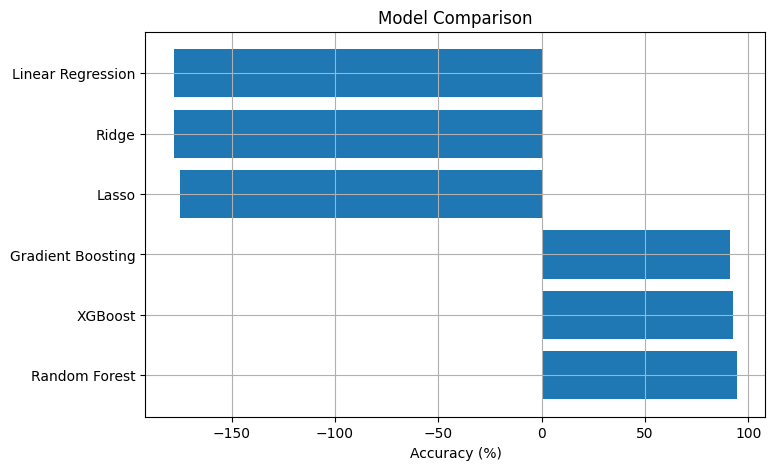

In [ ]:
plt.figure(figsize=(8,5))
plt.barh(comparison_df["Model"], comparison_df["Accuracy (%)"])
plt.xlabel("Accuracy (%)")
plt.title("Model Comparison")
plt.grid()
plt.show()

#VISUALIZATION

#ACTUAL VS PREDICTED

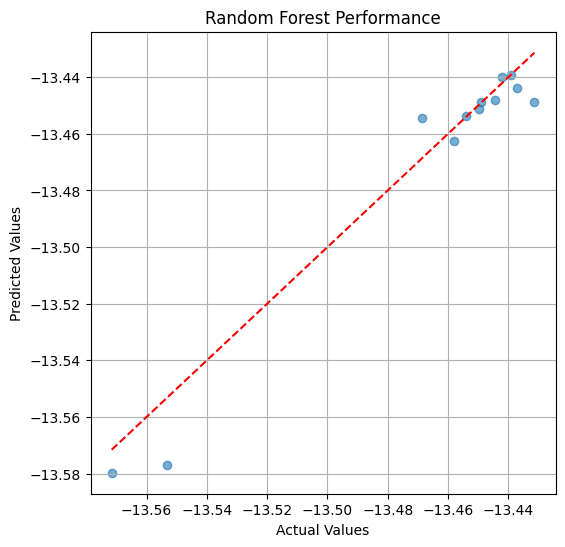

In [ ]:
y_best_pred = results[best_model_name]["predictions"]

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_best_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"{best_model_name} Performance")
plt.grid()
plt.show()

#FEATURE IMPORTANCE (TREE MODELS)


Top Features:

              Feature  Importance
0       Glucose_mg_dL    0.651670
2        S11_dB_2_2_4    0.342922
3  S11_freq_5_5_3_GHz    0.003674
1  S11_freq_2_2_4_GHz    0.001734


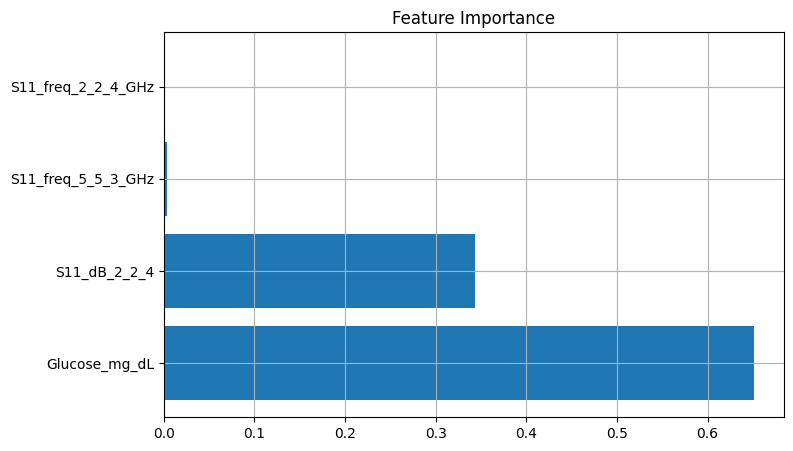

In [ ]:
if best_model_name in ["Random Forest", "Gradient Boosting", "XGBoost"]:
    importances = best_model.feature_importances_

    feature_df = pd.DataFrame({
        "Feature": X.columns,
        "Importance": importances
    }).sort_values("Importance", ascending=False)

    print("\nTop Features:\n")
    print(feature_df.head(10))

    plt.figure(figsize=(8,5))
    top_features = feature_df.head(10)
    plt.barh(top_features["Feature"], top_features["Importance"])
    plt.title("Feature Importance")
    plt.grid()
    plt.show()

#TEST SAMPLE PREDICTION

In [ ]:
# ============================================
# 📌 STEP 14: TEST SAMPLE PREDICTION + ACCURACY
# ============================================

print("\n===================================")
print("🔍 TEST SAMPLE PREDICTION")
print("===================================")

sample = X_test.iloc[0].values.reshape(1, -1)

# Scale if needed
if best_model_name in ["Linear Regression", "Ridge", "Lasso"]:
    sample = scaler.transform(sample)

prediction = best_model.predict(sample)[0]
actual = y_test.iloc[0]

# Calculate percentage accuracy (based on error)
error = abs(actual - prediction)
accuracy_percent = max(0, (1 - error / abs(actual))) * 100

print("Sample Input:\n", X_test.iloc[0])
print("\nActual Value:", actual)
print("Predicted Value:", prediction)

print("\n-----------------------------------")
print(f"Prediction Error: {error:.4f}")
print(f"Prediction Accuracy: {accuracy_percent:.2f}%")
print("-----------------------------------")


🔍 TEST SAMPLE PREDICTION
Sample Input:
 Glucose_mg_dL         0.0000
S11_freq_2_2_4_GHz    2.2295
S11_dB_2_2_4         -6.5287
S11_freq_5_5_3_GHz    5.1845
Name: 0, dtype: float64

Actual Value: -13.4372
Predicted Value: -13.443704480666668

-----------------------------------
Prediction Error: 0.0065
Prediction Accuracy: 99.95%
-----------------------------------
